# PCA 모델 생성

In [80]:
# 데이터 가져오기
import numpy as np

fruits=np.load('./data/fruits_300.npy')
fruits_2d=fruits.reshape(-1,100*100)
fruits_2d

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(300, 10000), dtype=uint8)

# PCA 학습

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=50) #만개의 특성중에 50개로만 해봐. 큰것부터 시작해서, 주성분의 개수 지정
pca.fit(fruits_2d)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [6]:
pca.components_

array([[-9.24490195e-06, -5.10601298e-06, -8.91640398e-06, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.69701620e-05,  1.13551051e-05,  1.82152567e-05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.65220446e-05, -2.08401737e-05, -2.89870104e-05, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       ...,
       [ 3.82011264e-05, -4.04361209e-06, -5.33813365e-06, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 3.88415200e-05,  9.73094704e-05,  1.24702662e-04, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.26926626e-05, -8.21389086e-05, -1.00315283e-04, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00]],
      shape=(50, 10000))

In [ ]:
#PCA 클래스가 찾은 주성분은 components_속성에 저장되어 있다. 
pca.components_.shape

(50, 10000)

#첫 번째 차원이 50,50개의 주성분을 찾은 거다.
#두번째 차원은 항상 원본 데이터의 특성 개수와 같은 10,000이다.

In [12]:
import matplotlib.pyplot as plt
def draw_fruits(arr, ratio=1):
    n=len(arr) # 0번이면 112, 셈플의 개수
    rows=int(np.ceil(n/10)) # 셈플 개수를 10으로 나누어 전체 행 개수를 계산합니다. 
    #'row가 2보다 작으면 cols=n, 아니면 cols=10
    cols=n if rows<2 else 10 

    fig, axs=plt.subplots(rows, cols, figsize=(cols*ratio, rows*ratio), squeeze=False)

    for i in range(rows):
        for j in range(cols):
            if i*10+j<n:
                axs[i,j].imshow(arr[i*10+j], cmap='gray_r')
            axs[i,j].axis('off')
    plt.show()

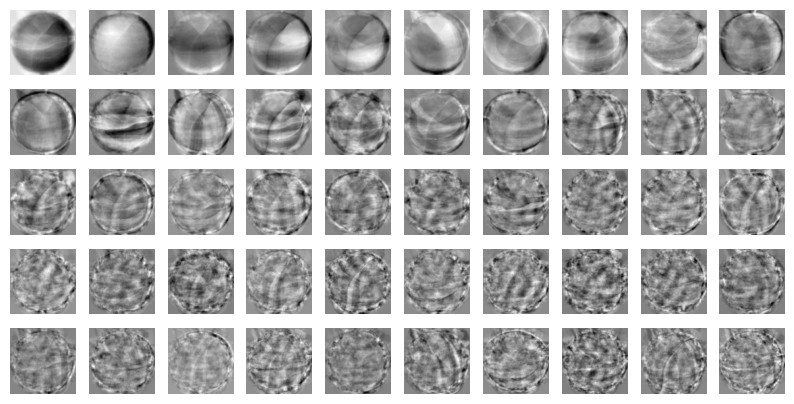

In [15]:

draw_fruits(pca.components_.reshape(-1, 100, 100))

In [ ]:
#이 주성분은 원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것이다.
#한편으로는 데이터 셋에 있는 어떤 특징을 잡아낸 것 처럼 생각할 수 있다. 

In [ ]:
#pca클래스가 찾은 주성분은 components_속성에 저장되어 있다. 
pca.components_.shape

#50개의 주성분을 찾은 거다.
#두번째 차원은 항상 원본 데이터의 특성개수와 같은 10000이다.
#50: 주성분 개수(새로운 축 개수)
#10000: 원래 특성 개수 

(50, 10000)

In [ ]:
fruits_2d.shape

#10000개의 픽셀을 가진 300개의 이미지
#300-> 이미지 개수(셈플)
#10000 -> 픽셀수(특성=차원)


(300, 10000)

# 차원축소

In [ ]:
# 차원축소는 픽셀수를 줄이는것이다.
fruits_pca=pca.transform(fruits_2d) #차원축소
fruits_pca.shape
#50개의 특성을 가진 300개의 이미지

(300, 50)

# 원본의 재구성


In [19]:
#PCA클래스는 inverse_transform()메서드를 제공한다.
#50개의 차원으로 축소한 fruits_pca데이터를 전달해 10000개를 복원해보자
fruits_inverse=pca.inverse_transform(fruits_pca)
fruits_inverse.shape

(300, 10000)

In [20]:
fruits_reconstruct=fruits_inverse.reshape(-1,100,100)

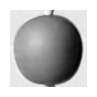

In [22]:
draw_fruits(fruits_reconstruct[0:1])

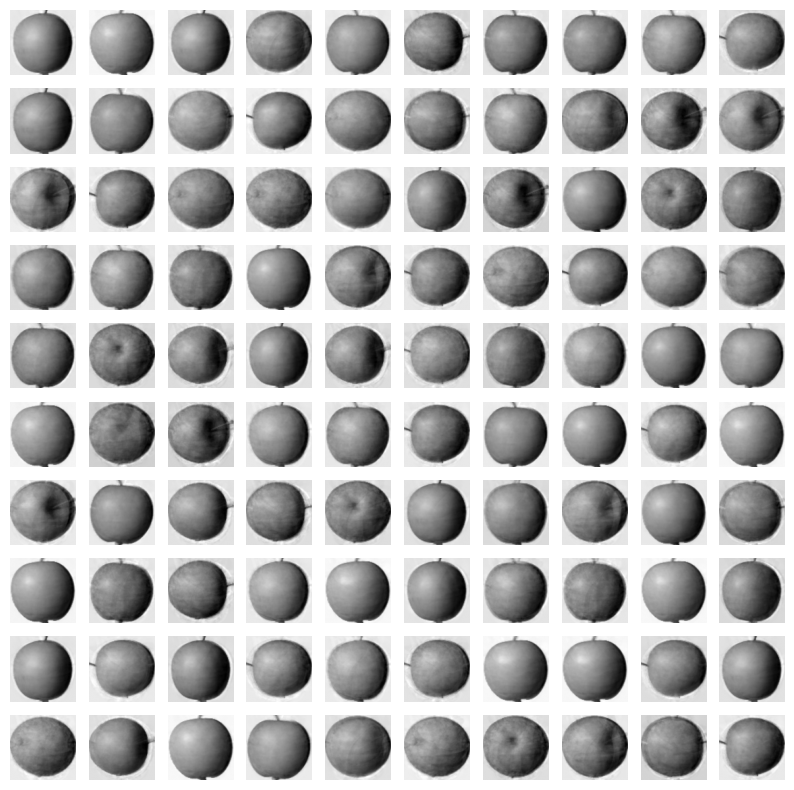

/n


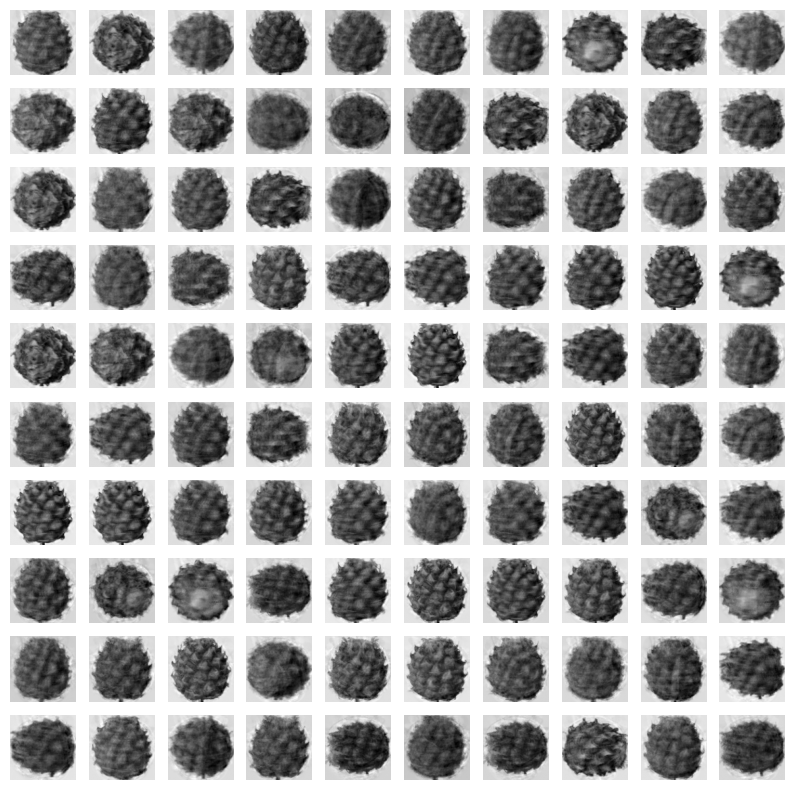

/n


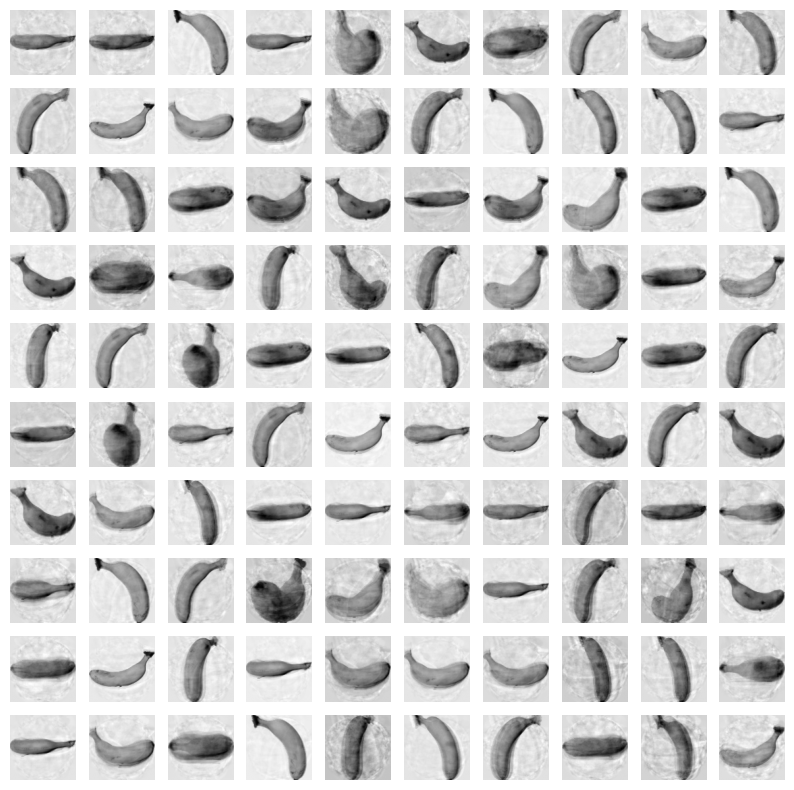

/n


In [ ]:
for start in [0,100,200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print('/n') #축소했다가 복원된거라 이미지가 조금 다름

# 설명된 분산
- 각 주성분이 데이터 분산을 얼마나 설명하는지 확인할 수 있다

In [32]:
pca.explained_variance_ratio_ # 50개의 픽셀중에 첫번째 것이 42페센트를 설명. 
#설명된 분산비율
#pca에서 각 주성분이 얼마나 중요한지 (%)

array([0.42357017, 0.09941755, 0.06577863, 0.04031172, 0.03416875,
       0.03281329, 0.02573267, 0.02054963, 0.01372276, 0.01342773,
       0.01152146, 0.00944596, 0.00878232, 0.00846697, 0.00693049,
       0.00645188, 0.00578895, 0.00511202, 0.00486381, 0.00480345,
       0.0044783 , 0.00437317, 0.00408036, 0.00389479, 0.00372443,
       0.00359291, 0.00331471, 0.00317809, 0.00304328, 0.00303757,
       0.00288839, 0.00275467, 0.00264992, 0.00255594, 0.00252003,
       0.00247152, 0.00239524, 0.00230842, 0.00222114, 0.0021652 ,
       0.00213684, 0.00196491, 0.00192902, 0.00191053, 0.00183929,
       0.00181925, 0.00173212, 0.00168085, 0.00161526, 0.00159506])

# 누적분산

In [34]:
np.sum(pca.explained_variance_ratio_) #분산을 다 더했더니 92%를 설명함. 
#앞에서 50개의 특성에서 원본 데이터를 복원했을 때 원본 이미지의 품질이 높았던 이유를 여기서 찾을 수 있다. 

np.float64(0.9215314082837177)

# 누적분산 그래프

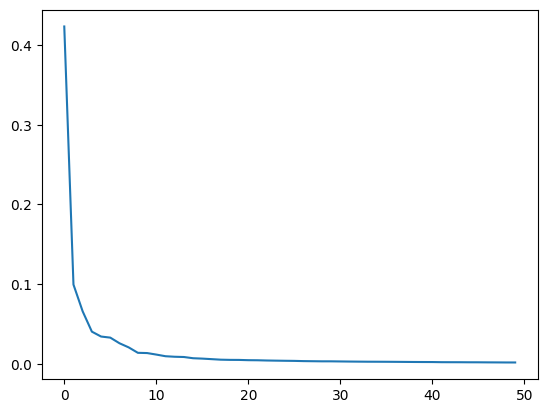

In [35]:
plt.plot(pca.explained_variance_ratio_)

In [ ]:
#처음 10개의 주성분이 대부분의 분산을 표현하고 있다. 

In [36]:
#PCA로 차원이 축소된 데이터를 사용하여 지도 학습 모델을 훈련하여 보자.
#원본데이터를 사용했을 때와 어떤 차이가 있는 지 확인해 보자. 

# 다른 알고리즘과 함께 사용하기

# PCA로 압축된 데이터 시각화

In [41]:
#3개의 과일사진 분류로 로지스틱회귀모델 사용
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [42]:
target=np.array([0]*100+[1]*100+[2]*100)

In [43]:
from sklearn.model_selection import cross_validate
#원본데이터
scores=cross_validate(lr,fruits_2d,target)
scores

{'fit_time': array([0.36711144, 0.26529121, 0.26529217, 0.40890718, 0.32114196]),
 'score_time': array([0.00298762, 0.00399661, 0.00299025, 0.00498676, 0.00299096]),
 'test_score': array([1.        , 1.        , 1.        , 0.98333333, 1.        ])}

In [45]:
print('훈련점수',np.mean(scores['test_score']))
print('훈련시간',np.mean(scores['fit_time']))

훈련점수 0.9966666666666667
훈련시간 0.325548791885376


In [46]:
#차원축소한 데이터
scores=cross_validate(lr, fruits_pca, target)
print('훈련점수',np.mean(scores['test_score']))
print('훈련시간',np.mean(scores['fit_time']))


훈련점수 0.9966666666666667
훈련시간 0.023535823822021483


In [ ]:
#50개의 특성을 사용했는데도 정확도가 100%이고 훈련시간은 20배이상 감소함
#PCA로 훈련데이터의 차원을 축소하면 저장 공간 뿐만 아니라 머신러신 모델의 훈련속도도 높일 수 있다. 


In [ ]:
# 설명된 분산이 50%에 달하는 주성분을 찾도록 pca모델을 만들어 보자

In [57]:
pca=PCA(n_components=0.5)
#전체 분산의 50% 주성분 찾기

In [58]:
pca.fit(fruits_2d)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [59]:
#pca클래스가 찾은 주성분은 components_속성에 저장되어 있다.

pca.n_components_

np.int64(2)

In [60]:
fruits_pca=pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [61]:
scores=cross_validate(lr, fruits_pca, target)
print('훈련점수',np.mean(scores['test_score']))
print('훈련시간',np.mean(scores['fit_time']))
#반복회수 증가 하라고 경고. 결과 충분히 좋기때문에 무시

훈련점수 0.9933333333333334
훈련시간 0.03447723388671875


c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://s

# 1️⃣2️⃣ PCA + K-means

In [62]:
# PCA로 차원 축소 후 군집

In [65]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [73]:
np.unique(km.labels_, return_counts=True)
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))

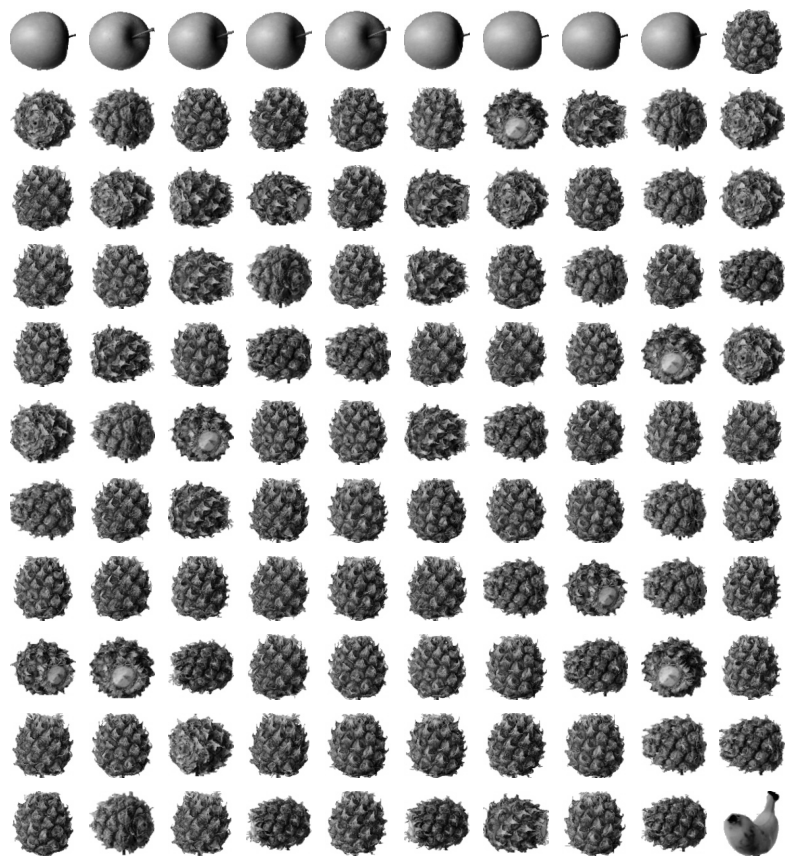

/n


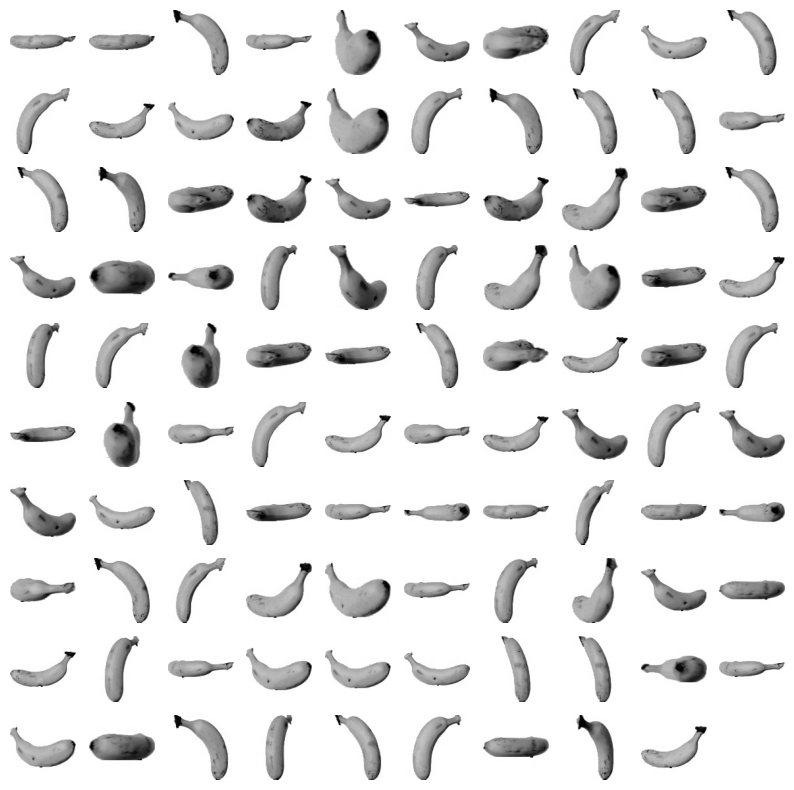

/n


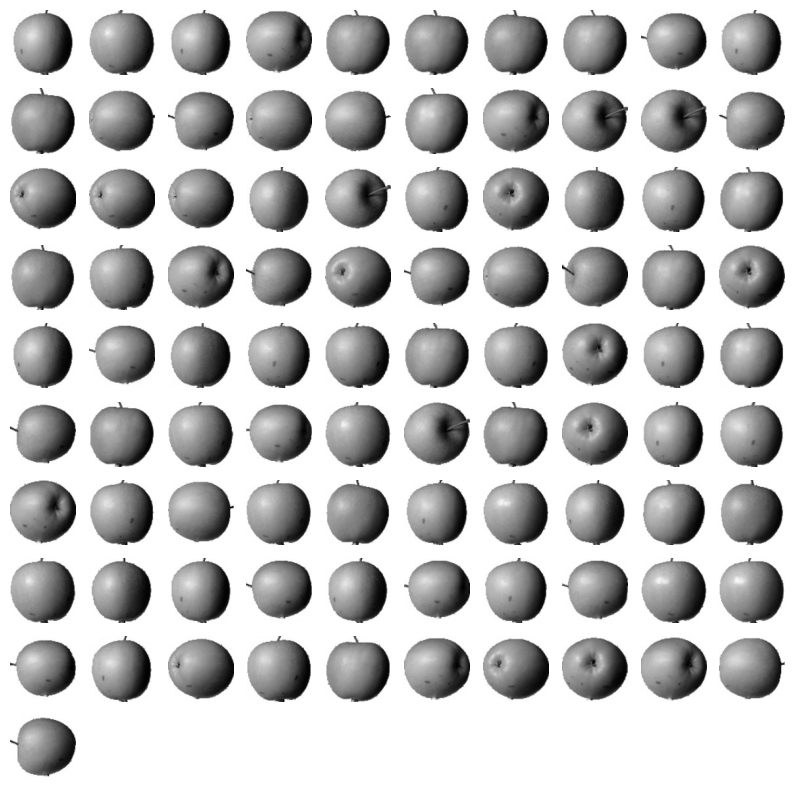

/n


In [68]:
for label in range(0,3):
    draw_fruits(fruits[km.labels_==label])
    
    print("/n")

In [ ]:
fruits_pca[km.labels_==0][:,0]
#fruits_pca데이터는 2개의 특성이 있기 때문에 2차원으로 표한할 수 있가.
#km.labels를 사용해 클러스터별로 나누어 산점도를 그려보자

array([1556.73860341, 2641.95018377, 2063.01348637, 2031.32316791,
       2860.74601791, 1682.34573388, 1619.90106151, 1522.5025055 ,
       1755.67284459, 2748.52503988, 1718.65422384, 2665.64509875,
       2507.88795773, 2706.37041042, 2527.51759862, 2373.07250421,
       2286.11484284, 2049.9426979 , 2663.68872032, 2254.03961645,
       2904.21051342, 2100.88738646, 2412.48005937,  976.7187988 ,
       2788.38246012, 2334.1415987 , 1759.63320415, 2687.81157433,
       1885.02057839, 2022.76017768, 2602.72053322, 2337.83084801,
       2134.27354073, 2964.95285092, 2262.0689292 , 1891.605049  ,
       2563.42114566, 2087.23899367, 2740.73189952, 2535.77493813,
       2417.39464414, 1764.84644165, 2823.64790411, 2636.84684269,
       2288.01592399, 2630.42710738, 2900.12226771, 2320.32081431,
       2345.87515433, 1777.77819381, 2210.57301355, 2348.10324421,
       1332.31738348, 2318.95052374, 2318.83358239, 1688.04416369,
       2044.5617155 , 2759.94004664, 2403.50161452, 2473.28075

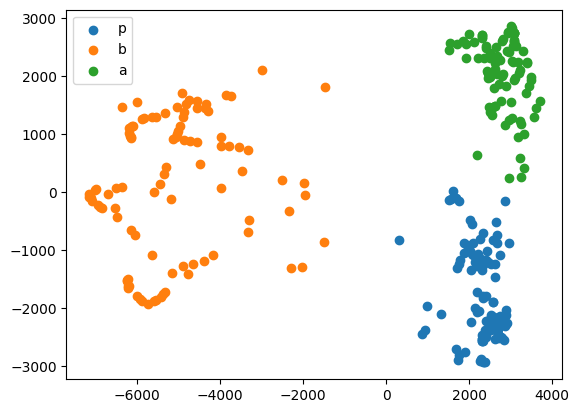

In [78]:
plt.scatter(fruits_pca[km.labels_==0][:,0],fruits_pca[km.labels_==0][:,1])
plt.scatter(fruits_pca[km.labels_==1][:,0],fruits_pca[km.labels_==1][:,1])
plt.scatter(fruits_pca[km.labels_==2][:,0],fruits_pca[km.labels_==2][:,1])
plt.legend(['p','b','a'])

plt.show()